<a href="https://colab.research.google.com/github/EricStimpsonWSU/CHiMaD-PFC-Demo/blob/main/PFC_Walkthrough_Instructions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PFC Walkthrough Instructions

###### Shared Folder Link & QR Code

In [ ]:
# @markdown ##### Install `qrcode` package
!pip install qrcode[pil]

In [ ]:
# @markdown ## Link to CHiMaD shared folder
import qrcode
from IPython.display import Image, display

# The URL for which to generate the QR code
qr_data = "https://drive.google.com/drive/folders/1aQT16rAJC359f8mcMUo-58fDBLOWymNU?usp=sharing"

# Generate the QR code
qr_img = qrcode.make(qr_data)

# Save the QR code image
qr_img_path = "CHiMaD_share_qr_code.png"
qr_img.save(qr_img_path)

print(f"QR code saved as {qr_img_path}")

# Display the QR code in the notebook
display(Image(filename=qr_img_path))

https://drive.google.com/drive/folders/1aQT16rAJC359f8mcMUo-58fDBLOWymNU?usp=sharing

## PFC Model Overview

This walkthrough implements a simple PFC Simulation with conserved dynamics and the following model:

$$
\partial_t \psi = \Gamma \nabla^2 \mu
$$

with

$$
\mu = B(\nabla^2 + q_0^2)^2 \psi + r \psi + g \psi^2 + v_0 \psi^3
$$

where $q_0$ sets the real-space length scale $a_0 = 4 \pi / \sqrt{3} q_0$ for the hexagonal (triangle) lattice:

# $\psi(\mathbf{r})$ for hexagonal lattice:
```
 o o o o
o o o o
 o o o o
o o o o
```

The algorithm in this implementation calculates derivatives in Fourier space and products (powers) in real space with exponential timestepping as described by [Cross, et al.](https://pubs.aip.org/aip/cha/article-abstract/4/4/607/135142/Chaotic-domains-A-numerical-investigationChaotic?redirectedFrom=PDF).

Timestepping equation:
$$
\tilde{\psi}(t + \Delta t) = \exp[\alpha \Delta t] \tilde{\psi}(t) + \tilde{N}\left[ \frac{\exp[\alpha \Delta t] - 1}{\alpha} \right]
$$

where

$$
\alpha = \Gamma [ -(r + B) k^2 + 2 B k^4 - B k^6]
$$

and

$$
N = g \psi^2 + v_0 \psi^3
$$

---
The simulation is written to use `float64` and `complex128` buffers for real-space and Fourier-space computations.

The algorithm is highly parallelizable, and well-suited to multicore CPUs or GPUs.  The implementation utilizes a data-layer abstraction that enables seamless switching between CPU / GPU runtimes for direct comparison.  Details of this abstraction can be found in a cell titled "CPU / GPU agnostic arrays: numpy / cupy as xp".

## Step 0 - Boilerplate

This is the entry point for the walkthrough.  To complete "Step 0", open the shared file...

[Step 0 Notebook](https://colab.research.google.com/drive/1YrfwrjT532hspuXMWj-_Gx6XfnWtdVZD?usp=drive_link)

... and run all.

In [ ]:
# @markdown ### Link to Step 0 shared file
import qrcode
from IPython.display import Image, display

# The URL for which to generate the QR code
qr_data = "https://colab.research.google.com/drive/1YrfwrjT532hspuXMWj-_Gx6XfnWtdVZD?usp=drive_link"

# Generate the QR code
qr_img = qrcode.make(qr_data)

# Save the QR code image
qr_img_path = "step_0_qr_code.png"
qr_img.save(qr_img_path)

print(f"QR code saved as {qr_img_path}")

# Display the QR code in the notebook
display(Image(filename=qr_img_path))

## Step 1 - Create simulation box, set initial state, & plotting.

The simulation box, `psi`, is implemented as a 2D array of floats with real coordinates [`Y`, `X`] and Fourier coordinates [`KY`, `KX`].  The size of the arrays are as follows:

```
psi[Ny,Nx]
x[Nx], kx[Nx]
y[Ny], ky[Ny]
```
* Note: Using `[row, col]` indexing.

For optimal (fast Fourier transform) FFT algorithmic efficiency, `Nx` $=$ `Ny` $= 2^n$.

The size of each element, `dx` $\times$ `dy`, sets the real-space box dimenstions to
```
Lx = Nx * dx
Ly = Ny * dy
```

For numeric stability, `dx`, `dy` $\le 0.9 \, q_0$ and `dx` $\approx$ `dy` is suggested.

#### 1) Locate the cell containing the sPFC class definition.

---
* Note: Python cares about indentation.  You must indent members of a class
```
class Foo:
  def bar():
    # statements
  # statement not in bar()
# statement not in Foo
```
and lines within `if` blocks
```
if cond:
  # statements in if
else: # [optional]
  # statement in else
# statement not in if block
```
and `for` blocks
```
for i in range(10):
  # statement in loop
# statement not in loop
```
Statements generally occupy a single row, but long calculations can be spread over multiple rows as long as they are contained in paranthesis:
```
value = (
  # expression +
  # expression +
  # ...
)
```
The same holds for function calls:
```
foo.bar(
  arg1,
  arg2,
)
```

#### 2) Replace `InitGeometry` function with the following code block

In [ ]:
  def InitGeometry(self, Nx, Ny, dx, dy) -> None:
    """ Create simulation box...

    Args:
    - Nx (int): Number of grid points in the x-direction.
    - Ny (int): Number of grid points in the y-direction.
    - dx (float): Grid spacing in the x-direction.
    - dy (float): Grid spacing in the y-direction

    Description:
    This method initializes the simulation grid and calculates the real-space
    and k-space dimensions.

    Returns:
    None
    """
    self.Nx = Nx
    self.Ny = Ny
    self.dx = dx
    self.dy = dy
    self.Lx = Nx * dx
    self.Ly = Ny * dy

    self.x = xp.linspace(0, self.Lx, self.Nx, endpoint=False)
    self.y = xp.linspace(0, self.Ly, self.Ny, endpoint=False)

    self.X, self.Y = xp.meshgrid(self.x, self.y)

    kx = xp.fft.fftfreq(self.Nx, self.dx) * 2 * xp.pi
    ky = xp.fft.fftfreq(self.Ny, self.dy) * 2 * xp.pi

    self.KX, self.KY = xp.meshgrid(kx, ky)
    return None

- This code creates member variables like `Nx`, `Ny`, etc., by utilizing the `self.` prefix (similar to `this.` in `C++`).

- The `x` and `y` axis are 1D arrays created by linearly spacing values `Nx` values over the interval `[0, Lx)` and similar for `y`.

- The `X` and `Y` are 2D arrays of size `[Ny, Nx]`, giving the $x$ and $y$ coordinate of each pixel in the field.

- The `kx`, `ky`, `KX`, `KY` are equivalent structures for the Fourier space coordinate system.  The datalayer's FFT library computes the $\mathbf{k}$ coordinates with proper shifting compatible with `FFTW` and `cuFFT` implementations.

---
* Note: NumPy's FFT, `npFFT` implements many of the FFT functions avaialble in `FFTW`, but they are single-threaded and in-place transforms are supported.  CuPy's FFT functions use `cuFFT` behind the scenes, but in-place transforms are not supported.  For this walkthrough, where switching runtime environments between CPU and GPU was designed to be seamless, in-place transforms were not used.

#### 3) Replace the `SetInitialState` with the following code block

In [ ]:
  def SetInitialState(self, psi0, sigma) -> None:
    """ Set initial simulation state using a Gaussian distribution.

    Args:
    - psi0 (numpy.ndarray): Average density.
    - sigma (numpy.ndarray): Standard deviation of the Gaussian distribution.

    Description:
    This method sets the initial state of the simulation using
    specified average density and a Gaussian distribution.  The
    average density is exact [optionally, low-pass filter].

    Returns:
    None
    """

    # create real and complex density fields for real and Fourier space
    size = (self.Ny, self.Nx)
    self.psi = xp.zeros(size, dtype = xp.float64)
    self.psi_hat = xp.zeros(size, dtype = xp.complex128)

    # initialize density with normal distribution
    self.psi[...] = xp.random.normal(loc=0, scale=sigma, size=(self.Ny, self.Nx))

    # Normalize to psi0 in k-space
    self.psi_hat[...] = xp.fft.fftn(self.psi)
    self.psi_hat[0,0] = psi0 * self.Nx * self.Ny

    # optional low-pass filter part 1:
    self.psi_hat[(self.KX**2 + self.KY**2) > (self.KX[0,16]**2 + self.KY[16,0]**2)] = 0

    self.psi[...] = xp.real(xp.fft.ifftn(self.psi_hat))

    # optional low-pass filter part 2 [sets or corrects distribution sigma]:
    self.psi[...] = (self.psi - self.psi.mean()) / self.psi.std() * sigma + self.psi.mean()

    # store initial state statistics
    self.psi0 = psi0
    self.psi_sigma = self.psi.std()
    return None


This code initializes the density field `psi` using a random distribution.  The field is created centered around `0`, and adjusted to the desired mean density `psi0` in Fourier space.  An optional low-pass filter [in two parts] can be commented out or left in place.  Statistics for the initial state are stored as a means of ensuring that density is conserved and similar sanity checks.

#### 4) Replace the `__repr__` function with the following code block

In [ ]:
  def __repr__(self) -> str:
    msg = 'Simple PFC Simulation'
    if hasattr(self, 'Nx'):
      # Get k-space resolution values
      dkx_val = self.KX[0, 1]
      dky_val = self.KY[1, 0]

      msg += (
          f"\n"
          f"  Simulation box: {self.Nx}x{self.Ny} (Nx x Ny)\n"
          f"  Real-space dimensions: {self.Lx:.4f} x {self.Ly:.4f} (Lx x Ly)\n"
          f"  Element size: {self.dx:.4f} x {self.dy:.4f} (dx x dy)\n"
          f"  K-space resolution: {dkx_val:.4f} x {dky_val:.4f} (dkx x dky)"
      )
    if hasattr(self, 'psi'):
      msg += (
          f"\n"
          f"  Initial density: {self.psi0:.4f}"
          f" +/- {self.psi_sigma:.4f}"
      )
    if hasattr(self, 't') and self.t > 0:
      msg += (
          f"\n"
          f"  Current density: {self.psi.mean():.4f}"
          f" +/- {self.psi.std():.4f}"
      )
    return msg


The `__repr__` member function (when defined) specifies simple output for the instances of the class when they are printed.  Printing is analagous to `cout >> ` in `C++`.

#### 5) Locate the cell where the simulation box is to be initialized and replace with the following code:

In [ ]:
# Initialize the simulation box
sim.InitGeometry(2**8, 2**8, 0.5, 0.5)
print(sim)

#### 6) The cell below sets the initial state.  Replace with the code:

In [ ]:
# Set initial state
sim.SetInitialState(-0.4, 0.5)
print(sim)

#### 7) The last step is to replace the code in the "View the initial state" and (optionally) "View the final state" cells.

In [ ]:
# View the initial state
import plotly.graph_objects as go

x = to_host_array(sim.x) # use 1D arrays for heatmap coords
y = to_host_array(sim.y)
Z = to_host_array(sim.psi)
fig = go.Figure(data=[go.Heatmap(
    x = x,
    y = y,
    z = Z,
    colorscale='Greys'
)])
fig.update_layout(
    title = 'Initial State',
    xaxis_title = 'x',
    yaxis_title = 'y',
    xaxis=dict(scaleanchor="y", scaleratio=1), # Ensure same scaling for x and y
    yaxis=dict(scaleanchor="x", scaleratio=1),
    width=600,  # Set a fixed width for consistent aspect ratio
    height=600, # Set a fixed height for consistent aspect ratio
    autosize=False
)
fig.show()

#### 8) Run all, review the output of each cell.

### Step 1 - Complete

If you followed along, your code should be similar to the notebook below, which you can open if you encountered any problems with the previous steps.

[Step 1 Notebook](https://colab.research.google.com/drive/1VeaaemhnRtLzmdWJ9JnqnrTvIBqQGswo?usp=drive_link)

... and run all.

## Step 2 - Setup the simulation model and implement timestepping logic.

The meat of the PFC simulation logic is implemented in two functions, `SetModelParms` and `Run`.  The first function precomputes the kernels used to calculate derivatives in Fourier space and for the exponential timestepping algorithm.  These kernels are dependent upon the specific model parameter values.  The second function implements the timestepping algorithm in the overview.

```
psi[Ny,Nx]
x[Nx], kx[Nx]
y[Ny], ky[Ny]
```
* Note: Using `[row, col]` indexing.

For optimal (fast Fourier transform) FFT algorithmic efficiency, `Nx` $=$ `Ny` $= 2^n$.

The size of each element, `dx` $\times$ `dy`, sets the real-space box dimenstions to
```
Lx = Nx * dx
Ly = Ny * dy
```

For numeric stability, `dx`, `dy` $\le 0.9 \, q_0$ and `dx` $\approx$ `dy` is suggested.

#### 1) Replace the `SetModelParams` method in `sPFC` with this code:

In [ ]:
  def SetModelParams(self, B, r, g, v0, dt) -> None:
    """ Set simulation parameters.

    Args:
    - B: Rigidity.
    - r: Temperature.
    - g: Cubic term.
    - v0: Quartic term.
    - dt: Timestep.

    Description:
    This method sets the PFC model parameters and calculates kernels used
    in timestepping.  Buffers are allocated for intermediate calculations.

    Returns:
    None
    """
    self.B = B
    self.r = r
    self.g = g
    self.v0 = v0
    self.dt = dt    # Δt

    # create real and complex buffers for timestep computation
    size = (self.Ny, self.Nx)
    self.psi2_hat = xp.zeros(size, dtype = xp.complex128)
    self.psi3_hat = xp.zeros(size, dtype = xp.complex128)
    self.nonlin_mu_hat = xp.zeros(size, dtype = xp.complex128)
    self.psi_t_p_dt_hat = xp.zeros(size, dtype = xp.complex128)
    self.kernel_d2_dlap = xp.zeros(size, dtype = xp.float64)
    self.kernel_d4_dlap2 = xp.zeros(size, dtype = xp.float64)
    self.kernel_d6_dlap3 = xp.zeros(size, dtype = xp.float64)
    self.kernel_lin_dpsidt = xp.zeros(size, dtype = xp.float64)
    self.kernel_linexp_dpsidt = xp.zeros(size, dtype = xp.float64)
    self.kernel_nonlinexp_dpsidt = xp.zeros(size, dtype = xp.float64)

    # define kernels in Fourier space
    self.kernel_d2_dlap[...] = -(self.KX * self.KX + self.KY * self.KY)         # ∇^2
    self.kernel_d4_dlap2[...] = self.kernel_d2_dlap * self.kernel_d2_dlap       # ∇^4
    self.kernel_d6_dlap3[...] = self.kernel_d4_dlap2 * self.kernel_d2_dlap      # ∇^6

    # define linear timestep kernel
    self.kernel_lin_dpsidt[...] = (
        (self.r + self.B) * self.kernel_d2_dlap +
        2 * self.B * self.kernel_d4_dlap2 +
        self.B * self.kernel_d6_dlap3
      )                                                                         # α

    # define linear and nonlinear exponential timestep kernel
    self.kernel_linexp_dpsidt[...] = xp.exp(self.kernel_lin_dpsidt * self.dt)

    self.kernel_nonlinexp_dpsidt[...] = xp.ones_like(self.kernel_lin_dpsidt) * self.dt
    self.kernel_nonlinexp_dpsidt[self.kernel_lin_dpsidt != 0] = (
        (self.kernel_linexp_dpsidt[self.kernel_lin_dpsidt != 0] - 1) / self.kernel_lin_dpsidt[self.kernel_lin_dpsidt != 0]
    )
    self.t = 0. * self.dt

    return None

This code defines the kernels used by the exponential timestepping algorithm.  Comments indicate which part of the key equations they implement.
---
* Note: The assignment of values to a field is accomplished with syntax like `field[...] =` instead of `field =`.  The former does in-place assignment, while the latter replaces the definition of the `field` variable completely.  The RHS of these assignments is calculated in memory (system or GPU, depending on the runtime) using elementwise calculations.  Both CPU and GPU elementwise calculations are handled by the appropriate datalayer and are implemented behind the scenes as standard `c`-style loops.

#### 2) Replace the `Run` method in `sPFC` with this code:

In [ ]:
  def Run(self, steps) -> None:
    """ Run simulation...

    Args:
    - steps (int): Number of timesteps to run.

    Description:
    This method runs the simulation for the specified number of steps
    using exponential timestepping.

    Returns:
    None
    """

    for step in range(steps):
      # build nonlinear term in Fourier space
      self.psi2_hat[...] = xp.fft.fftn(self.psi * self.psi)
      self.psi3_hat[...] = xp.fft.fftn(self.psi * self.psi * self.psi)
      self.nonlin_mu_hat[...] = (
          self.g * self.psi2_hat +
          self.v0 * self.psi3_hat)

      # calculate ψ[t + Δt](k) in Fourier space
      self.psi_hat[...] = xp.fft.fftn(self.psi)
      self.psi_t_p_dt_hat[...] = (
          self.kernel_linexp_dpsidt * self.psi_hat +
          self.kernel_d2_dlap * self.kernel_nonlinexp_dpsidt * self.nonlin_mu_hat
      )

      # convert to density to realspace
      self.psi[...] = xp.real(xp.fft.ifftn(self.psi_t_p_dt_hat))

      # update time
      self.t += self.dt

    return None

This code implements the exponential timestepping algorithm for this simple PFC model.

#### 3) The cell below sets the model parmaters state.  Replace with the code:

In [ ]:
# Set model parameters for timestepping
sim.SetModelParams(
    B = 1,
    r = -0.5,
    g = 0,
    v0 = 1,
    dt = 1e-1)
print(sim)

* Note: the use of argument names was not required because all required arguments were passed in the correct order.  However, it does help with legibility.

#### 4) The cell below sets the runs the simulation.  Replace with the code:

In [ ]:
# Run the simulation for 1000 steps
sim.Run(1000)
print(sim)

For the simulation box size specified in this walkthrough (256x256), 1000 steps takes around 8 seconds.

#### 5) If you didn't before, replace the post-run plotting cell with the code:

In [ ]:
import plotly.graph_objects as go

x = to_host_array(sim.x) # use 1D arrays for heatmap coords
y = to_host_array(sim.y)
Z = to_host_array(sim.psi)
fig = go.Figure(data=[go.Heatmap(
    x = x,
    y = y,
    z = Z,
    colorscale='Greys_r'
)])
fig.update_layout(
    title = 'Final State',
    xaxis_title = 'x',
    yaxis_title = 'y',
    xaxis=dict(scaleanchor="y", scaleratio=1), # Ensure same scaling for x and y
    yaxis=dict(scaleanchor="x", scaleratio=1),
    width=600,  # Set a fixed width for consistent aspect ratio
    height=600, # Set a fixed height for consistent aspect ratio
    autosize=False
)
fig.show()

#### 6) Run all, review the output of each cell

The simulation code is now complete and you should see plots of an initial randomized state and the result of running for PFC time $t = 100 \tau$.  You can now play with the model.  The following are a list of things to try:

a) Change the system size.  On a CPU runtime, 512x512, 1000 steps takes around 40 seconds.  1024x1024, 1000 steps takes around 3 minutes.

b) Switch runtimes to GPU.  From the menu, Runtime>Change Runtime Type brings up available options.  With a free account, you can choose the `G4` GPU runtime.  On the `G4`, a 1024x1024, 10 000 steps  takes around 4 seconds.

c) Modify the initial conditions and model parameters to explorer other areas of the parameter space.  A simplified $g=0$ phase diagram is shown here for reference.  This diagram shows temperature as $\epsilon$, $r$ in this code on the $y$-axis and $\overline{n}$ density, $\psi_0$ in this code on the $x$-axis.

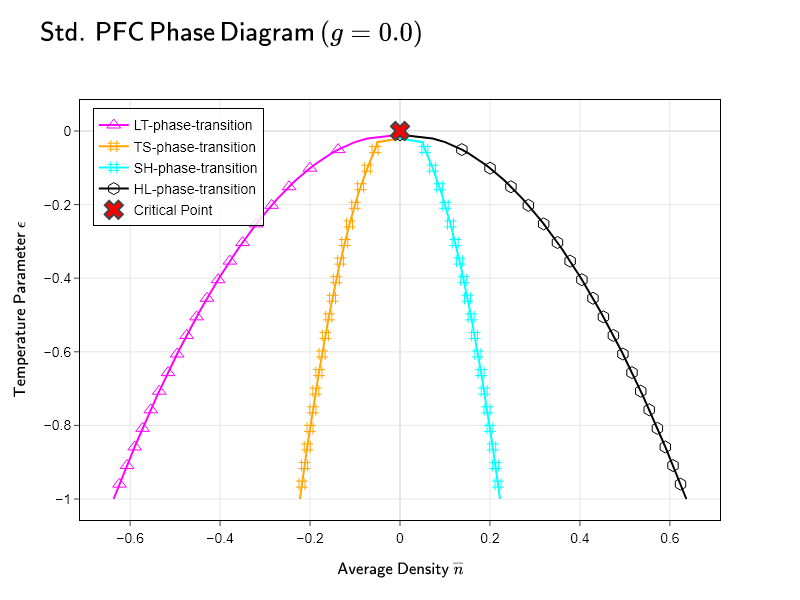